In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import duckdb

# set global pandas display settings
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

In [151]:
# import full dataset and split to prevent data leakage in EDA

df = pd.read_csv(r'/Users/wes/Desktop/DS207/merged_fire_data_10.csv')

print('Before split: ', df.shape)
df['DATE'] = pd.to_datetime(df['DATE'])

df = df[df['DATE'] <= '2009-12-27']
print('After split: ', df.shape)

Before split:  (20710, 108)
After split:  (12426, 108)


In [17]:
df.head()

,conus_code,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,INC_NUM,CAUSE,ACRES,longitude,latitude,county,conus_name,DURATION,fire_occurrences,T2M_0404,T2M_RANGE_0404,T2M_MAX_0404,T2M_MIN_0404,QV2M_0404,RH2M_0404,PRECTOTCORR_0404,WS10M_0404,WS10M_MAX_0404,WS10M_MIN_0404,WS10M_RANGE_0404,WD10M_0404,T2M_0401,T2M_RANGE_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401,PRECTOTCORR_0401,WS10M_0401,WS10M_MAX_0401,WS10M_MIN_0401,WS10M_RANGE_0401,WD10M_0401,T2M_0403,T2M_RANGE_0403,T2M_MAX_0403,T2M_MIN_0403,QV2M_0403,RH2M_0403,PRECTOTCORR_0403,WS10M_0403,WS10M_MAX_0403,WS10M_MIN_0403,WS10M_RANGE_0403,WD10M_0403,T2M_0402,T2M_RANGE_0402,T2M_MAX_0402,T2M_MIN_0402,QV2M_0402,RH2M_0402,PRECTOTCORR_0402,WS10M_0402,WS10M_MAX_0402,WS10M_MIN_0402,WS10M_RANGE_0402,WD10M_0402,T2M_0405,T2M_RANGE_0405,T2M_MAX_0405,T2M_MIN_0405,QV2M_0405,RH2M_0405,PRECTOTCORR_0405,WS10M_0405,WS10M_MAX_0405,WS10M_MIN_0405,WS10M_RANGE_0405,WD10M_0405,T2M_0406,T2M_RANGE_0406,T2M_MAX_0406,T2M_MIN_0406,QV2M_0406,RH2M_0406,PRECTOTCORR_0406,WS10M_0406,WS10M_MAX_0406,WS10M_MIN_0406,WS10M_RANGE_0406,WD10M_0406,T2M_0407,T2M_RANGE_0407,T2M_MAX_0407,T2M_MIN_0407,QV2M_0407,RH2M_0407,PRECTOTCORR_0407,WS10M_0407,WS10M_MAX_0407,WS10M_MIN_0407,WS10M_RANGE_0407,WD10M_0407
0,not_used,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,7.51,11.94,15.51,3.57,5.61,84.72,0.01,2.13,2.44,1.75,0.69,23.2,2.59,8.81,8.46,-0.35,4.12,79.57,0.00,2.06,2.59,1.22,1.37,12.8,-1.97,6.05,2.10,-3.95,3.34,89.63,0.02,1.25,2.57,0.21,2.36,75.8,8.71,11.44,16.42,4.98,6.00,86.44,0.05,3.34,4.81,1.36,3.45,17.8,6.11,12.50,14.18,1.68,4.12,63.23,0.07,3.18,4.67,0.27,4.40,60.3,13.77,7.39,18.51,11.12,5.32,54.97,0.01,8.67,12.00,6.45,5.55,30.6,6.13,10.36,12.60,2.24,2.85,46.50,0.00,5.88,9.39,3.55,5.84,31.5
1,not_used,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,8.94,13.62,16.85,3.23,5.18,70.86,0.00,2.10,3.06,1.28,1.78,85.2,5.13,8.81,10.55,1.74,4.61,73.98,0.00,2.48,2.88,1.69,1.19,3.9,-1.53,8.55,3.31,-5.24,3.01,78.85,0.02,0.97,1.53,0.30,1.23,55.3,8.63,12.78,16.94,4.16,5.97,86.49,0.01,3.10,4.69,0.74,3.95,30.0,7.19,11.74,14.90,3.16,4.19,58.96,0.18,3.47,5.60,0.68,4.92,62.5,12.30,7.91,17.38,9.47,4.20,48.15,0.00,9.19,11.54,6.76,4.78,33.1,4.17,12.79,11.76,-1.03,1.97,37.85,0.00,6.41,10.54,4.62,5.92,39.7
2,not_used,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,11.91,11.49,18.85,7.36,5.06,55.88,0.01,1.25,1.91,0.59,1.32,97.6,7.93,9.69,14.23,4.54,6.35,84.50,0.03,2.36,2.79,1.55,1.24,1.3,0.39,9.53,6.26,-3.27,2.80,63.38,0.09,0.79,1.71,0.17,1.54,36.5,10.20,14.42,18.78,4.36,7.51,93.91,0.67,3.38,4.20,2.22,1.98,18.2,8.81,13.03,16.50,3.47,4.73,59.32,0.06,2.61,4.48,0.51,3.97,65.2,13.03,9.39,19.10,9.71,4.75,51.24,0.00,7.02,8.75,4.37,4.38,33.7,5.44,14.29,14.12,-0.17,2.27,39.57,0.00,4.58,7.30,2.83,4.47,43.6
3,not_used,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,13.28,11.88,20.37,8.49,5.07,51.25,0.00,1.62,2.21,0.79,1.42,122.9,6.79,10.01,13.15,3.14,6.02,87.89,0.00,2.05,2.72,0.95,1.77,17.0,1.26,8.18,6.61,-1.57,3.64,74.57,0.14,1.36,2.29,0.37,1.92,52.6,11.97,12.95,20.61,7.66,7.35,84.68,0.06,2.91,3.77,1.02,2.75,25.9,11.05,11.35,18.42,7.07,6.28,69.22,0.04,3.06,4.53,0.42,4.11,65.6,14.69,9.49,20.80,11.31,5.63,54.45,0.00,6.03,7.83,2.08,5.75,37.0,7.57,14.11,16.15,2.04,3.48,50.91,0.00,4.66,7.89,3.09,4.80,44.0
4,not_used,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,12.48,12.86,20.22,7.36,5.79,62.41,0.01,1.43,2.77,0.20,2.57,86.7,6.18,10.40,13.18,2.78,5.69,85.38,0.16,2.27,2.78,1.20,1.58,12.9,-0.06,6.54,4.69,-1.85,4.10,92.84,0.90,1.18,1.85,0

Below, we will iterate through all NASA meterology weather columns and set values to NaN when we are uncertain of whether a fire started in that climate region. Values were otherwise set to 0 prior for modeling purposes, but need to be set to NaN for proper visualization in EDA.

In [155]:
# temperature: T2M, T2M_RANGE, T2M_MAX, T2M_MIN

# T2M
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'T2M_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'T2M_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'T2M_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'T2M_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'T2M_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'T2M_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'T2M_0407'] = np.nan
        
# T2M_RANGE
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'T2M_RANGE_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'T2M_RANGE_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'T2M_RANGE_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'T2M_RANGE_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'T2M_RANGE_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'T2M_RANGE_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'T2M_RANGE_0407'] = np.nan
        
# T2M_MAX
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'T2M_MAX_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'T2M_MAX_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'T2M_MAX_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'T2M_MAX_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'T2M_MAX_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'T2M_MAX_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'T2M_MAX_0407'] = np.nan
        
# T2M_MIN
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'T2M_MIN_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'T2M_MIN_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'T2M_MIN_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'T2M_MIN_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'T2M_MIN_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'T2M_MIN_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'T2M_MIN_0407'] = np.nan

In [97]:
# humidity/precipitation: QV2M, RH2M, PRECTOTCORR

# QV2M
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'QV2M_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'QV2M_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'QV2M_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'QV2M_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'QV2M_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'QV2M_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'QV2M_0407'] = np.nan
        
# RH2M
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'RH2M_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'RH2M_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'RH2M_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'RH2M_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'RH2M_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'RH2M_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'RH2M_0407'] = np.nan
        
# PRETOTCORR
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'PRECTOTCORR_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'PRECTOTCORR_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'PRECTOTCORR_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'PRECTOTCORR_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'PRECTOTCORR_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'PRECTOTCORR_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'PRECTOTCORR_0407'] = np.nan

In [98]:
# wind speeed/direction: WS10M, WS10M_MAX, WS10M_MIN, WS10M_RANGE, WD10M
    
# WS10M
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'WS10M_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'WS10M_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'WS10M_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'WS10M_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'WS10M_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'WS10M_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'WS10M_0407'] = np.nan

# WS10M_MAX
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'WS10M_MAX_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'WS10M_MAX_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'WS10M_MAX_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'WS10M_MAX_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'WS10M_MAX_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'WS10M_MAX_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'WS10M_MAX_0407'] = np.nan
        
# WS10M_MIN
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'WS10M_MIN_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'WS10M_MIN_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'WS10M_MIN_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'WS10M_MIN_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'WS10M_MIN_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'WS10M_MIN_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'WS10M_MIN_0407'] = np.nan
        
# WS10M_RANGE
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'WS10M_RANGE_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'WS10M_RANGE_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'WS10M_RANGE_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'WS10M_RANGE_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'WS10M_RANGE_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'WS10M_RANGE_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'WS10M_RANGE_0407'] = np.nan
        
# WD10M
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '401.0':
        df.at[index, 'WD10M_0401'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '402.0':
        df.at[index, 'WD10M_0402'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '403.0':
        df.at[index, 'WD10M_0403'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '404.0':
        df.at[index, 'WD10M_0404'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '405.0':
        df.at[index, 'WD10M_0405'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '406.0':
        df.at[index, 'WD10M_0406'] = np.nan
for index, row in df.iterrows():
    if row['FIRE_START_DAY'] == True and row['conus_code'] != '407.0':
        df.at[index, 'WD10M_0407'] = np.nan

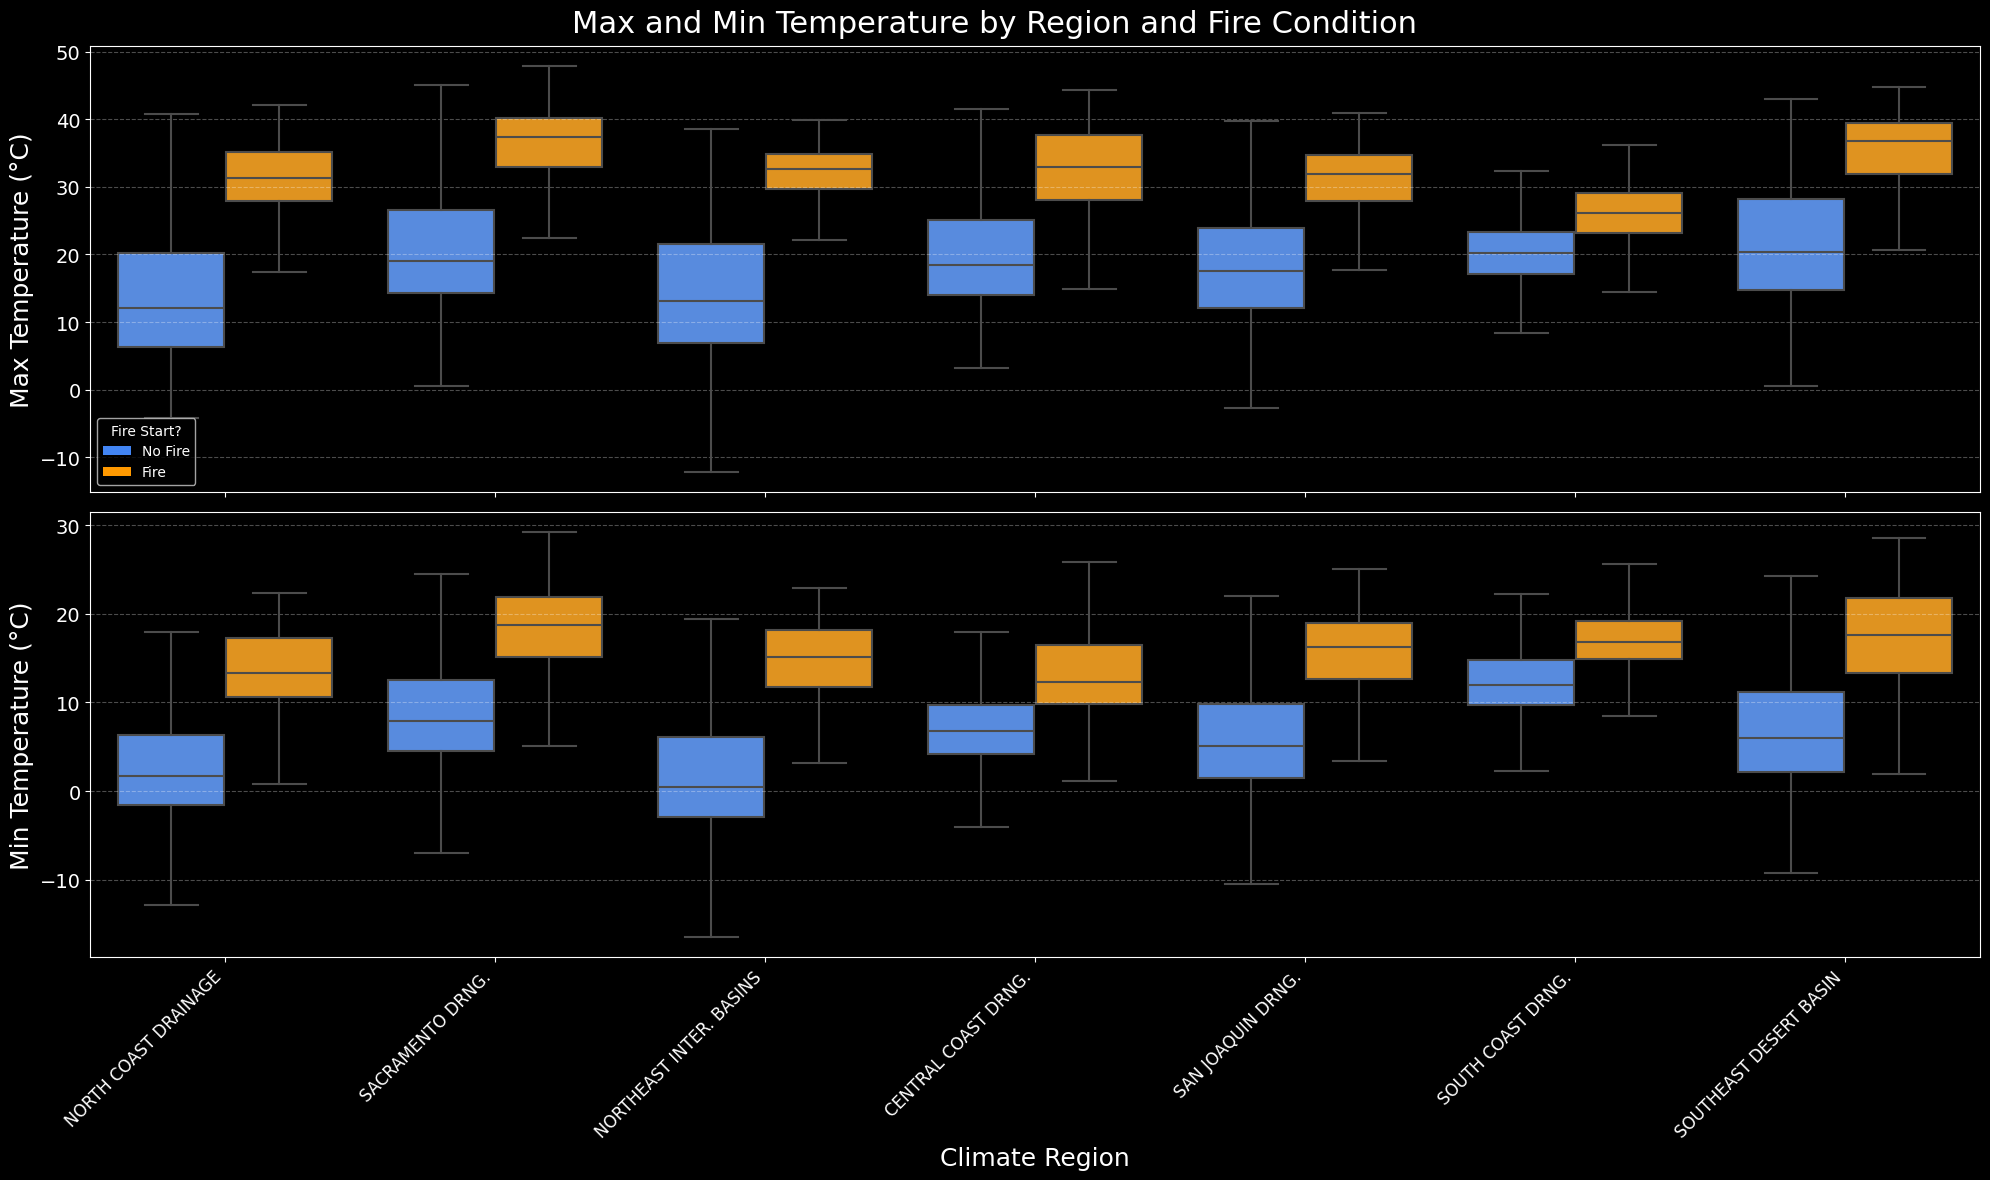

In [68]:
# set the global settings to dark background for presentation
plt.style.use('dark_background')

# generate figure and 2 suplots w/ black facecolor formatting
fig, axes = plt.subplots(2,1
                         , figsize=(20,12)
                         , sharex=True
                         , facecolor='black')
fig.patch.set_facecolor('black')

# create mapping dictionaries for both the T2M_MAX and T2M_MIN box plots used with pd.melt()
region_mapping_max = {
    'T2M_MAX_0401': 'NORTH COAST DRAINAGE'
    , 'T2M_MAX_0402': 'SACRAMENTO DRNG.'
    , 'T2M_MAX_0403': 'NORTHEAST INTER. BASINS'
    , 'T2M_MAX_0404': 'CENTRAL COAST DRNG.'
    , 'T2M_MAX_0405': 'SAN JOAQUIN DRNG.'
    , 'T2M_MAX_0406': 'SOUTH COAST DRNG.'
    , 'T2M_MAX_0407': 'SOUTHEAST DESERT BASIN'
}

region_mapping_min = {
    'T2M_MIN_0401': 'NORTH COAST DRAINAGE'
    , 'T2M_MIN_0402': 'SACRAMENTO DRNG.'
    , 'T2M_MIN_0403': 'NORTHEAST INTER. BASINS'
    , 'T2M_MIN_0404': 'CENTRAL COAST DRNG.'
    , 'T2M_MIN_0405': 'SAN JOAQUIN DRNG.'
    , 'T2M_MIN_0406': 'SOUTH COAST DRNG.'
    , 'T2M_MIN_0407': 'SOUTHEAST DESERT BASIN'
}

t2m_max_columns = ['T2M_MAX_0401', 'T2M_MAX_0402', 'T2M_MAX_0403', 
                  'T2M_MAX_0404', 'T2M_MAX_0405', 'T2M_MAX_0406', 'T2M_MAX_0407']
t2m_min_columns = ['T2M_MIN_0401', 'T2M_MIN_0402', 'T2M_MIN_0403', 
                  'T2M_MIN_0404', 'T2M_MIN_0405', 'T2M_MIN_0406', 'T2M_MIN_0407']

# generate melted dfs to use more easily with box plot visuals with each of the 7 columns
meltdf_max = pd.DataFrame()
for i in t2m_max_columns:
    temp = df[['FIRE_START_DAY',i]].copy()
    temp['variable'] = i
    temp.rename(columns={i:'value'}, inplace=True)
    meltdf_max = pd.concat([meltdf_max, temp])
    
meltdf_min = pd.DataFrame()
for i in t2m_min_columns:
    temp = df[['FIRE_START_DAY',i]].copy()
    temp['variable'] = i
    temp.rename(columns={i:'value'}, inplace=True)
    meltdf_min = pd.concat([meltdf_min, temp])
    
# generate the top box plot
sns.boxplot(x = 'variable'
           , y = 'value'
           , hue = 'FIRE_START_DAY'
           , data = meltdf_max
           , palette = {False: '#4285F4', True: '#FF9900'} # blue, orange
           , showfliers = False
           , ax = axes[0])

# generate the bottom box plot
sns.boxplot(x = 'variable'
           , y = 'value'
           , hue = 'FIRE_START_DAY'
           , data = meltdf_min
           , palette = {False: '#4285F4', True: '#FF9900'} # blue, orange
           , showfliers = False
           , ax = axes[1])

# axes formatting
axes[0].set_xlabel('') # remove the top box plot x label
axes[0].set_ylabel('Max Temperature (°C)',fontsize=18,color='white')
axes[0].tick_params(axis='y',labelsize=14,colors='white')
axes[0].grid(axis='y', linestyle='--', alpha=0.3,color='white')

axes[1].set_xlabel('Climate Region',fontsize=18,color='white') # set shared x axis label
axes[1].set_ylabel('Min Temperature (°C)',fontsize=18,color='white')
axes[1].tick_params(axis='y', labelsize=14,colors='white')
axes[1].grid(axis='y', linestyle='--',alpha=0.3,color='white')

axes[0].set_xticklabels([]) # remove ticks from top plot
axes[1].set_xticks(range(len(t2m_min_columns)))
axes[1].set_xticklabels([region_mapping_min[col] for col in t2m_min_columns],
                        fontsize=12, rotation=45, ha='right', color='white')
axes[1].get_legend().remove() # remove legend from bottom plot
axes[0].legend(handles=legend_elements, title='Fire Start?') # set legend title

# global formatting
fig.suptitle('Max and Min Temperature by Region and Fire Condition',fontsize=22,color='white')
plt.subplots_adjust(top=0.92) # ensures there is sufficient room for title

# save figure for presentation
plt.savefig('temp_boxplot.png',dpi=300,bbox_inches='tight',facecolor='black')

plt.tight_layout()
plt.show()

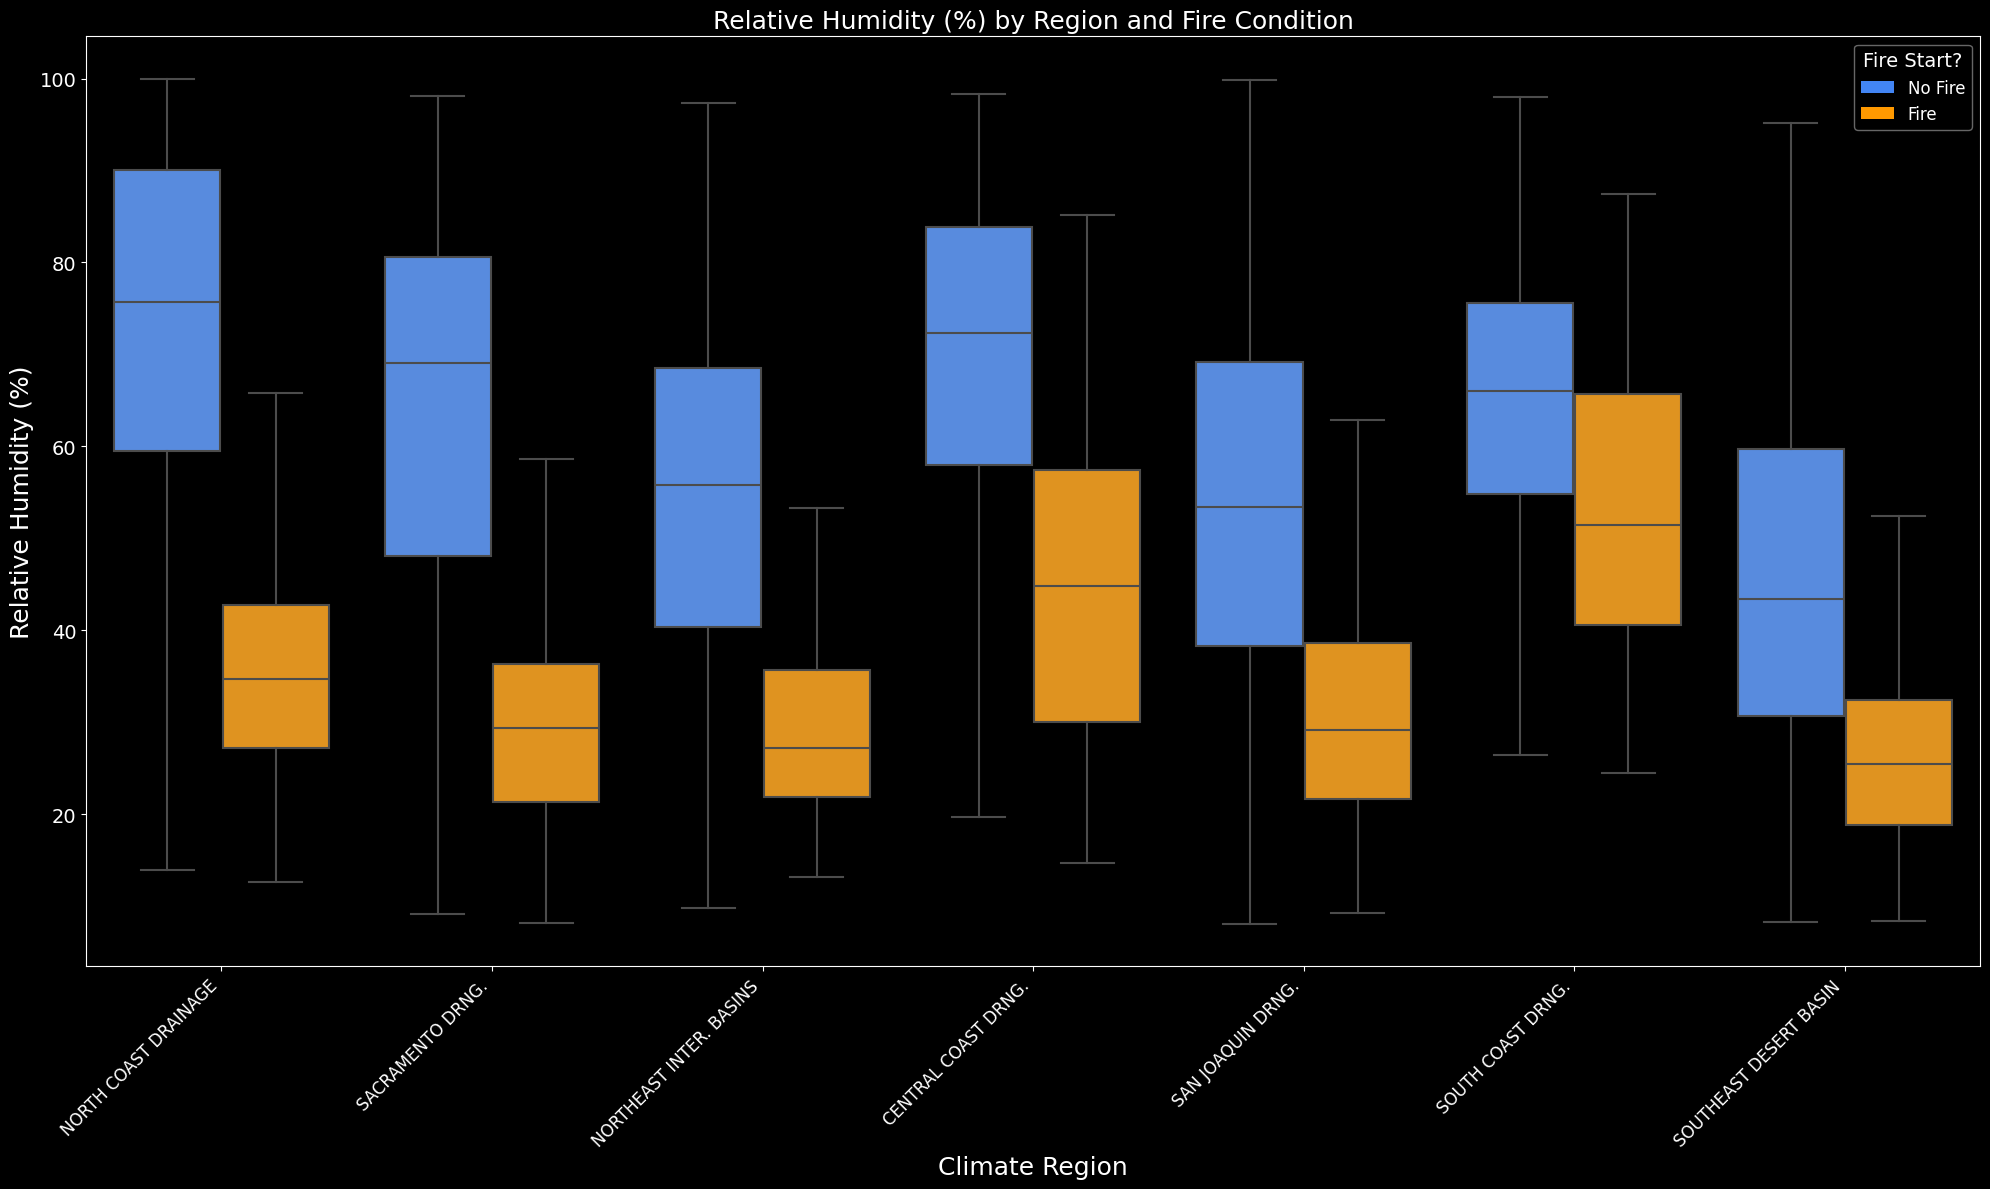

In [69]:
# set the global settings to dark background for presentation
plt.style.use('dark_background')
plt.figure(figsize=(20, 12))

# create mapping dictionaries for both the RH2M box plots used with pd.melt()
region_mapping = {
    'RH2M_0401': 'NORTH COAST DRAINAGE',
    'RH2M_0402': 'SACRAMENTO DRNG.',
    'RH2M_0403': 'NORTHEAST INTER. BASINS',
    'RH2M_0404': 'CENTRAL COAST DRNG.',
    'RH2M_0405': 'SAN JOAQUIN DRNG.',
    'RH2M_0406': 'SOUTH COAST DRNG.',
    'RH2M_0407': 'SOUTHEAST DESERT BASIN'
}

t2m_columns = ['RH2M_0401', 'RH2M_0402', 'RH2M_0403', 'RH2M_0404', 'RH2M_0405', 'RH2M_0406', 'RH2M_0407']

# generate melted dfs to use more easily with box plot visuals with each of the 7 columns
meltdf = pd.DataFrame()
for i in t2m_columns:
    temp = df[['FIRE_START_DAY',i]].copy()
    temp['variable'] = i
    temp.rename(columns={i:'value'}, inplace=True)
    meltdf = pd.concat([meltdf, temp])
    
# generate box plot
sns.boxplot(x = 'variable'
           , y = 'value'
           , hue = 'FIRE_START_DAY'
           , data = meltdf
           , palette = {False: '#4285F4', True: '#FF9900'} # blue, orange
           , showfliers = False
)

# formatting
plt.title('Relative Humidity (%) by Region and Fire Condition',fontsize=18,color='white')
plt.xlabel('Climate Region',fontsize=18,color='white')
plt.ylabel('Relative Humidity (%)',fontsize=18,color='white')
plt.yticks(fontsize=14, color='white')
plt.xticks( # replaces column names with climate region names
    range(len(t2m_columns))
    , [region_mapping[col] for col in t2m_columns]
    , fontsize=12
    , rotation=45
    , ha='right'
    , color='white'
)

plt.legend(handles=legend_elements
           , title='Fire Start?'
           , framealpha=0.8
           , title_fontsize=14
           , fontsize=12
           , facecolor='black'
           , edgecolor='gray'
)
plt.savefig('humidity_boxplot.png',dpi=300,bbox_inches='tight',facecolor='black')
plt.tight_layout()

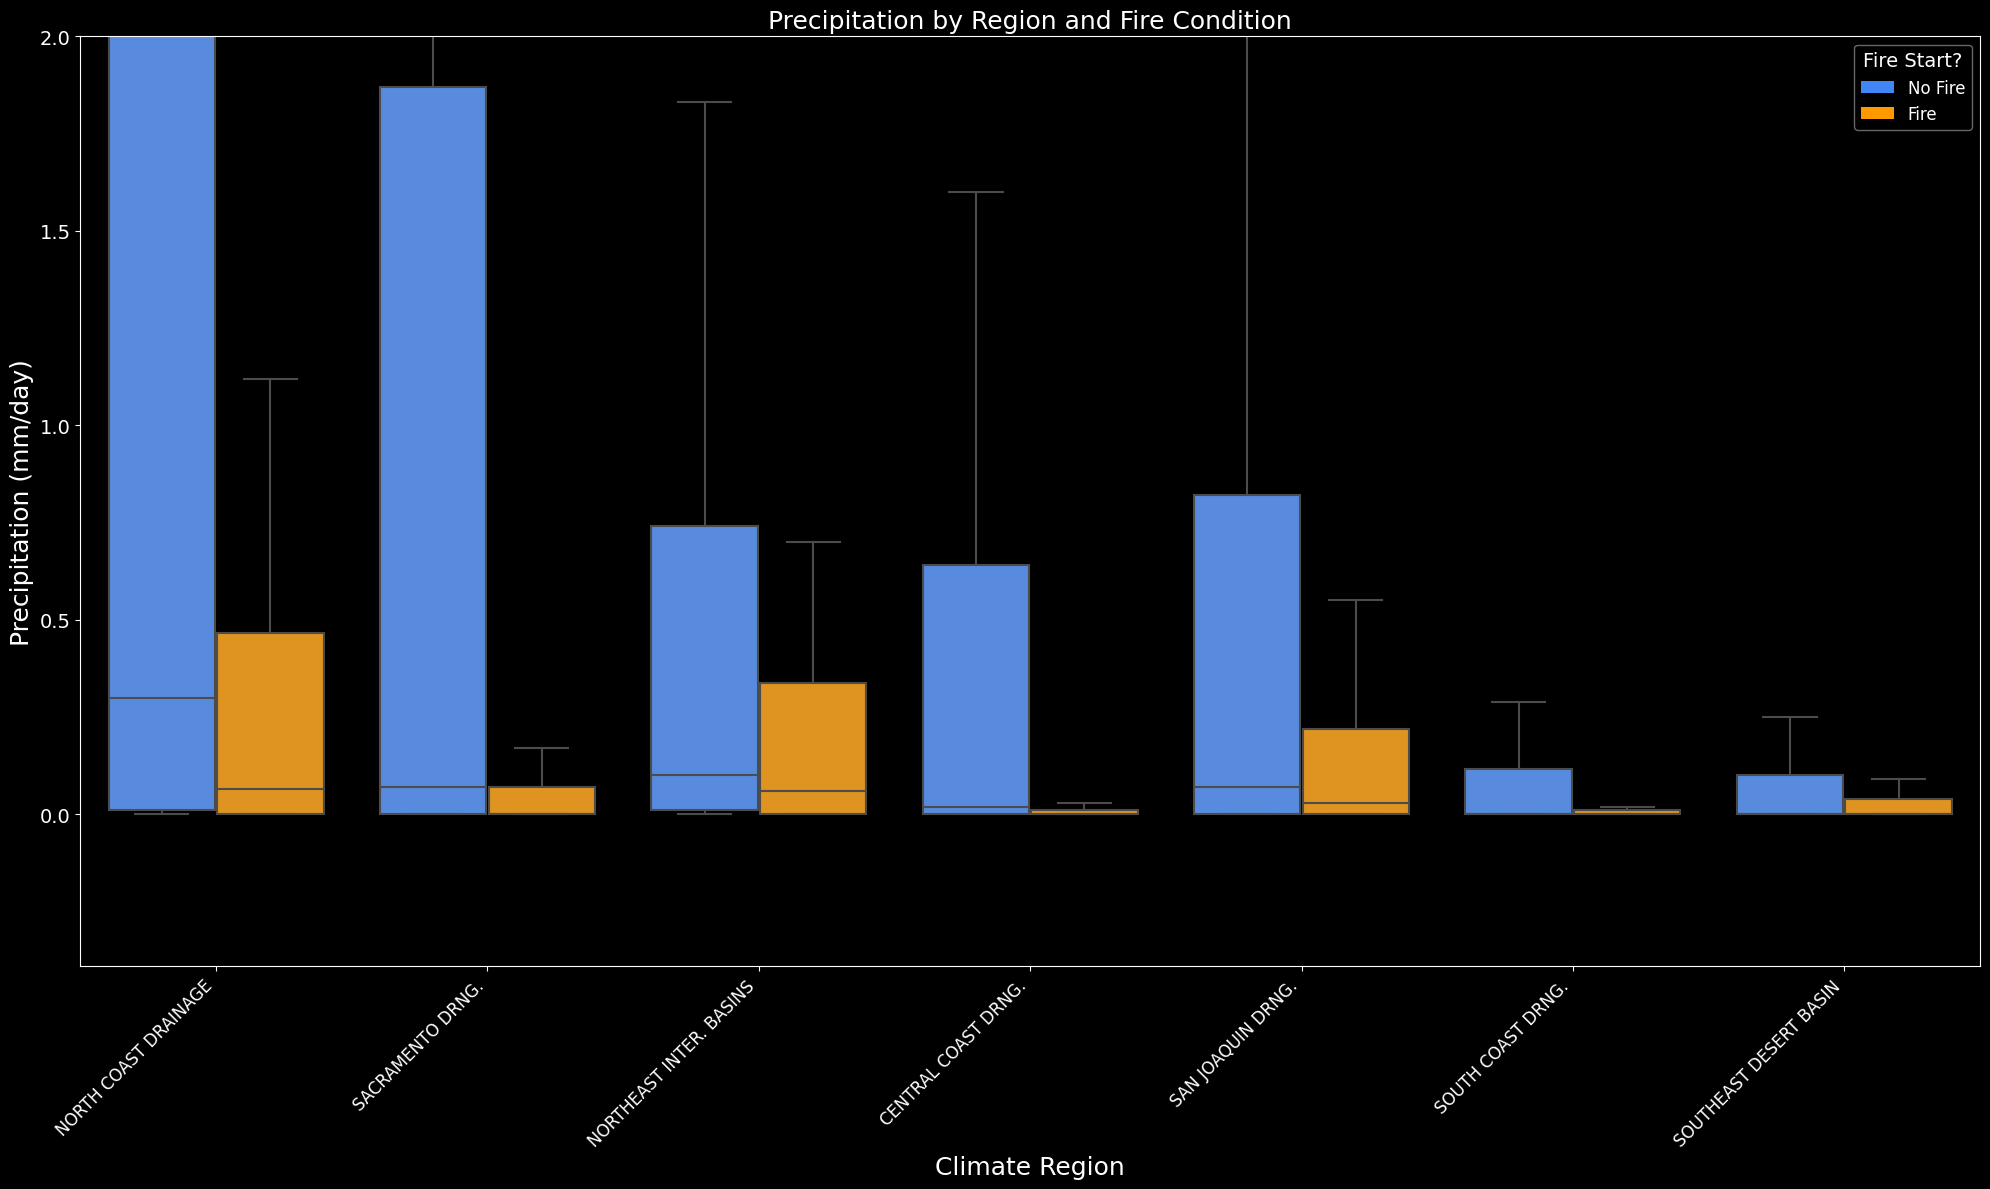

In [77]:
# set the global settings to dark background for presentation
plt.style.use('dark_background')
plt.figure(figsize=(20, 12))

# create mapping dictionaries for both the RH2M box plots used with pd.melt()
region_mapping = {
    'PRECTOTCORR_0401': 'NORTH COAST DRAINAGE',
    'PRECTOTCORR_0402': 'SACRAMENTO DRNG.',
    'PRECTOTCORR_0403': 'NORTHEAST INTER. BASINS',
    'PRECTOTCORR_0404': 'CENTRAL COAST DRNG.',
    'PRECTOTCORR_0405': 'SAN JOAQUIN DRNG.',
    'PRECTOTCORR_0406': 'SOUTH COAST DRNG.',
    'PRECTOTCORR_0407': 'SOUTHEAST DESERT BASIN'
}

t2m_columns = ['PRECTOTCORR_0401', 'PRECTOTCORR_0402', 'PRECTOTCORR_0403', 'PRECTOTCORR_0404', 'PRECTOTCORR_0405', 'PRECTOTCORR_0406', 'PRECTOTCORR_0407']

# generate melted dfs to use more easily with box plot visuals with each of the 7 columns
meltdf = pd.DataFrame()
for i in t2m_columns:
    temp = df[['FIRE_START_DAY',i]].copy()
    temp['variable'] = i
    temp.rename(columns={i:'value'}, inplace=True)
    meltdf = pd.concat([meltdf, temp])
    
# generate box plot
ax = sns.boxplot(x = 'variable'
           , y = 'value'
           , hue = 'FIRE_START_DAY'
           , data = meltdf
           , palette = {False: '#4285F4', True: '#FF9900'} # blue, orange
           , showfliers = False
)

# formatting
ax.set_ylim(top=2) 
plt.title('Precipitation by Region and Fire Condition',fontsize=18,color='white')
plt.xlabel('Climate Region',fontsize=18,color='white')
plt.ylabel('Precipitation (mm/day)',fontsize=18,color='white')
plt.yticks(fontsize=14, color='white')
plt.xticks( # replaces column names with climate region names
    range(len(t2m_columns))
    , [region_mapping[col] for col in t2m_columns]
    , fontsize=12
    , rotation=45
    , ha='right'
    , color='white'
)

plt.legend(handles=legend_elements
           , title='Fire Start?'
           , framealpha=0.8
           , title_fontsize=14
           , fontsize=12
           , facecolor='black'
           , edgecolor='gray'
)
plt.savefig('precipitation_boxplot.png',dpi=300,bbox_inches='tight',facecolor='black')
plt.tight_layout()

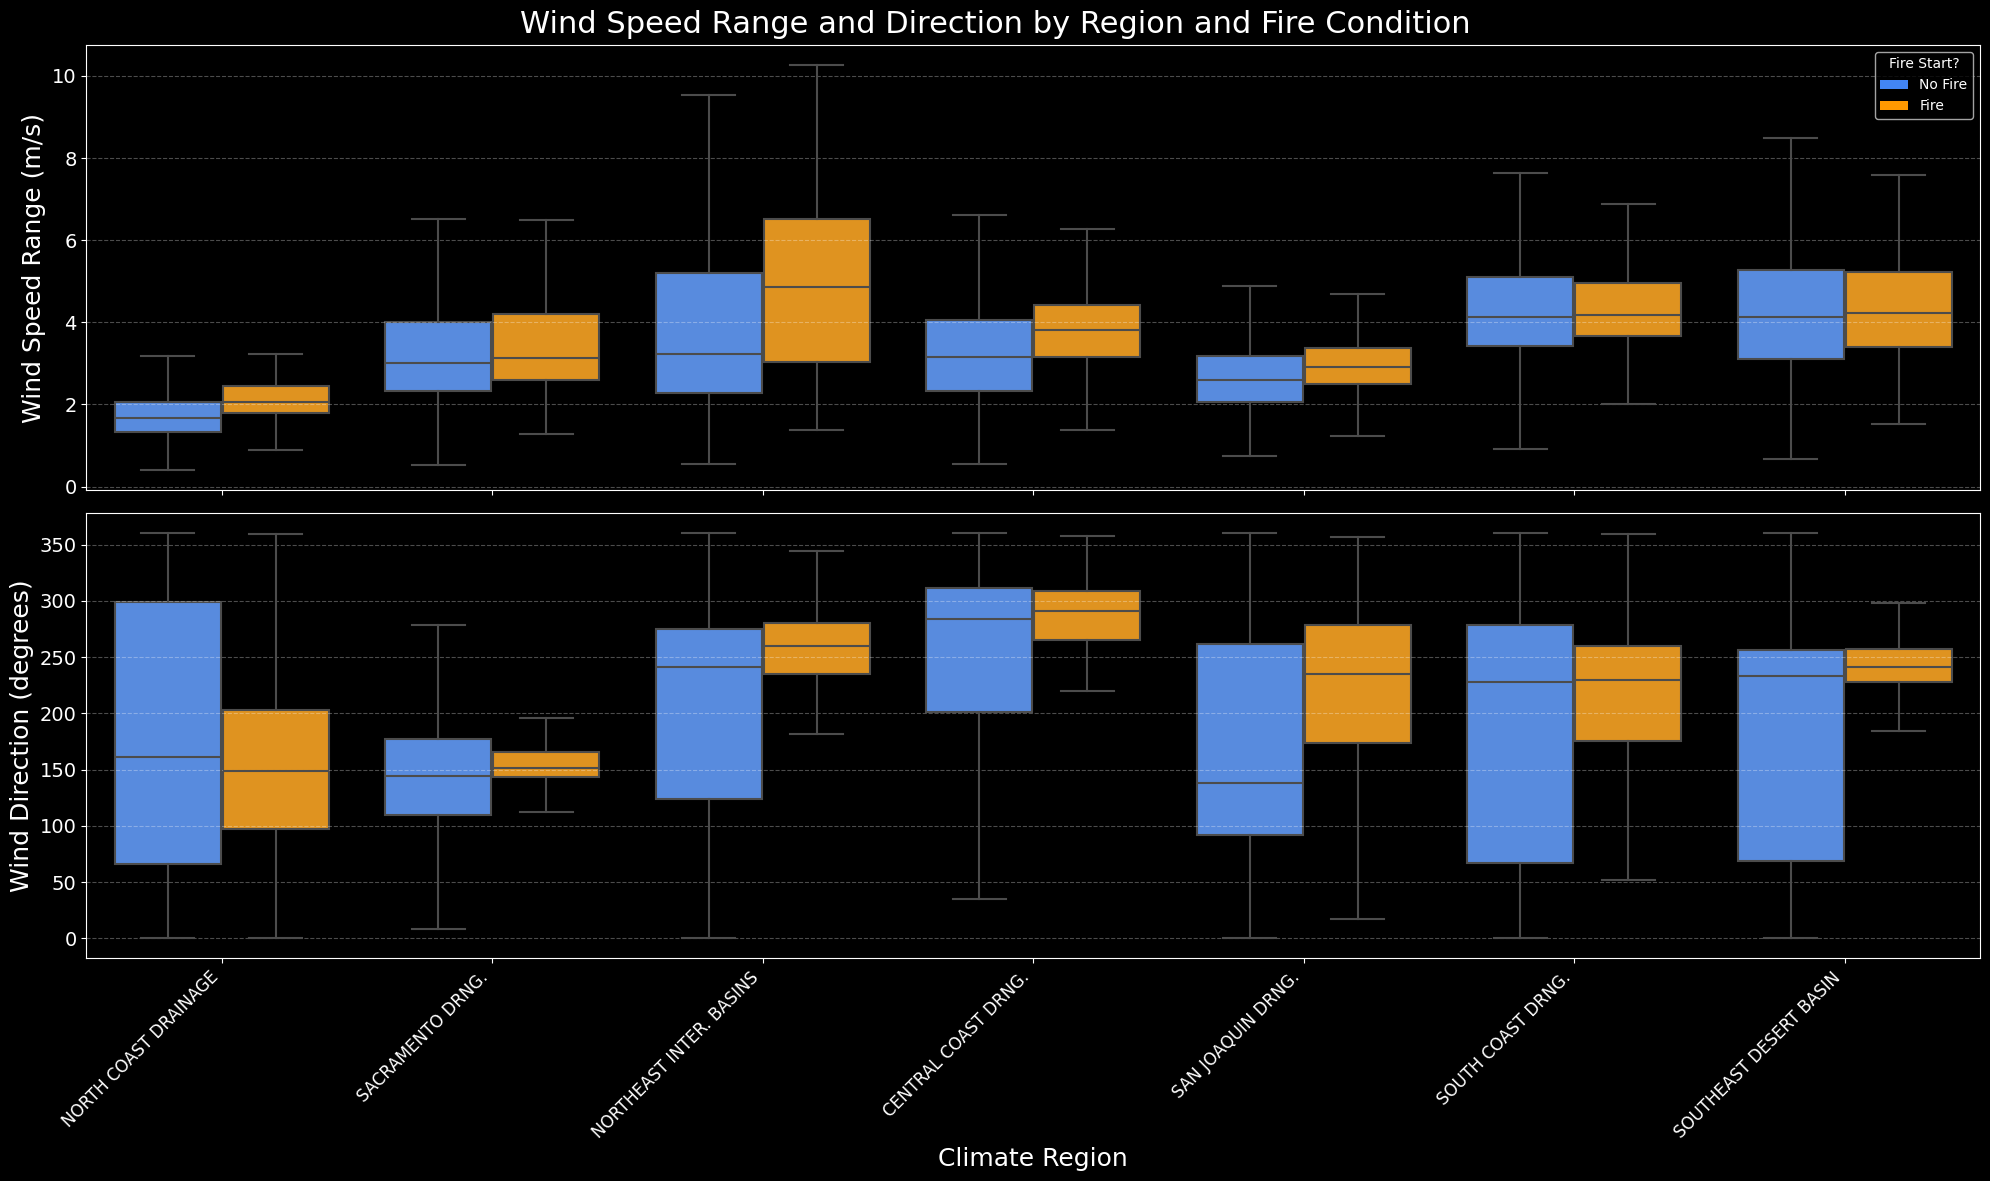

In [80]:
# set the global settings to dark background for presentation
plt.style.use('dark_background')

# generate figure and 2 suplots w/ black facecolor formatting
fig, axes = plt.subplots(2,1
                         , figsize=(20,12)
                         , sharex=True
                         , facecolor='black')
fig.patch.set_facecolor('black')

# create mapping dictionaries for both the WS10M_RANGE and WD10M box plots used with pd.melt()
region_mapping_range = {
    'WS10M_RANGE_0401': 'NORTH COAST DRAINAGE',
    'WS10M_RANGE_0402': 'SACRAMENTO DRNG.',
    'WS10M_RANGE_0403': 'NORTHEAST INTER. BASINS',
    'WS10M_RANGE_0404': 'CENTRAL COAST DRNG.',
    'WS10M_RANGE_0405': 'SAN JOAQUIN DRNG.',
    'WS10M_RANGE_0406': 'SOUTH COAST DRNG.',
    'WS10M_RANGE_0407': 'SOUTHEAST DESERT BASIN'
}

region_mapping_dir = {
    'WD10M_0401': 'NORTH COAST DRAINAGE',
    'WD10M_0402': 'SACRAMENTO DRNG.',
    'WD10M_0403': 'NORTHEAST INTER. BASINS',
    'WD10M_0404': 'CENTRAL COAST DRNG.',
    'WD10M_0405': 'SAN JOAQUIN DRNG.',
    'WD10M_0406': 'SOUTH COAST DRNG.',
    'WD10M_0407': 'SOUTHEAST DESERT BASIN'
}

t2m_range_columns = ['WS10M_RANGE_0401', 'WS10M_RANGE_0402', 'WS10M_RANGE_0403', 'WS10M_RANGE_0404', 'WS10M_RANGE_0405', 'WS10M_RANGE_0406', 'WS10M_RANGE_0407']
t2m_dir_columns = ['WD10M_0401', 'WD10M_0402', 'WD10M_0403', 'WD10M_0404', 'WD10M_0405', 'WD10M_0406', 'WD10M_0407']

# generate melted dfs to use more easily with box plot visuals with each of the 7 columns
meltdf_range = pd.DataFrame()
for i in t2m_range_columns:
    temp = df[['FIRE_START_DAY',i]].copy()
    temp['variable'] = i
    temp.rename(columns={i:'value'}, inplace=True)
    meltdf_range = pd.concat([meltdf_range, temp])
    
meltdf_dir = pd.DataFrame()
for i in t2m_dir_columns:
    temp = df[['FIRE_START_DAY',i]].copy()
    temp['variable'] = i
    temp.rename(columns={i:'value'}, inplace=True)
    meltdf_dir = pd.concat([meltdf_dir, temp])
    
# generate the top box plot
sns.boxplot(x = 'variable'
           , y = 'value'
           , hue = 'FIRE_START_DAY'
           , data = meltdf_range
           , palette = {False: '#4285F4', True: '#FF9900'} # blue, orange
           , showfliers = False
           , ax = axes[0])

# generate the bottom box plot
sns.boxplot(x = 'variable'
           , y = 'value'
           , hue = 'FIRE_START_DAY'
           , data = meltdf_dir
           , palette = {False: '#4285F4', True: '#FF9900'} # blue, orange
           , showfliers = False
           , ax = axes[1])

# axes formatting
axes[0].set_xlabel('') # remove the top box plot x label
axes[0].set_ylabel('Wind Speed Range (m/s)',fontsize=18,color='white')
axes[0].tick_params(axis='y',labelsize=14,colors='white')
axes[0].grid(axis='y', linestyle='--', alpha=0.3,color='white')

axes[1].set_xlabel('Climate Region',fontsize=18,color='white') # set shared x axis label
axes[1].set_ylabel('Wind Direction (degrees)',fontsize=18,color='white')
axes[1].tick_params(axis='y', labelsize=14,colors='white')
axes[1].grid(axis='y', linestyle='--',alpha=0.3,color='white')

axes[0].set_xticklabels([]) # remove ticks from top plot
axes[1].set_xticks(range(len(t2m_min_columns)))
axes[1].set_xticklabels([region_mapping_min[col] for col in t2m_min_columns],
                        fontsize=12, rotation=45, ha='right', color='white')
axes[1].get_legend().remove() # remove legend from bottom plot
axes[0].legend(handles=legend_elements, title='Fire Start?') # set legend title

# global formatting
fig.suptitle('Wind Speed Range and Direction by Region and Fire Condition',fontsize=22,color='white')
plt.subplots_adjust(top=0.92) # ensures there is sufficient room for title

# save figure for presentation
plt.savefig('wind_boxplot.png',dpi=300,bbox_inches='tight',facecolor='black')

plt.tight_layout()
plt.show()

In [81]:
df.head()

,conus_code,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR,INC_NUM,CAUSE,ACRES,longitude,latitude,county,conus_name,DURATION,fire_occurrences,T2M_0404,T2M_RANGE_0404,T2M_MAX_0404,T2M_MIN_0404,QV2M_0404,RH2M_0404,PRECTOTCORR_0404,WS10M_0404,WS10M_MAX_0404,WS10M_MIN_0404,WS10M_RANGE_0404,WD10M_0404,T2M_0401,T2M_RANGE_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401,PRECTOTCORR_0401,WS10M_0401,WS10M_MAX_0401,WS10M_MIN_0401,WS10M_RANGE_0401,WD10M_0401,T2M_0403,T2M_RANGE_0403,T2M_MAX_0403,T2M_MIN_0403,QV2M_0403,RH2M_0403,PRECTOTCORR_0403,WS10M_0403,WS10M_MAX_0403,WS10M_MIN_0403,WS10M_RANGE_0403,WD10M_0403,T2M_0402,T2M_RANGE_0402,T2M_MAX_0402,T2M_MIN_0402,QV2M_0402,RH2M_0402,PRECTOTCORR_0402,WS10M_0402,WS10M_MAX_0402,WS10M_MIN_0402,WS10M_RANGE_0402,WD10M_0402,T2M_0405,T2M_RANGE_0405,T2M_MAX_0405,T2M_MIN_0405,QV2M_0405,RH2M_0405,PRECTOTCORR_0405,WS10M_0405,WS10M_MAX_0405,WS10M_MIN_0405,WS10M_RANGE_0405,WD10M_0405,T2M_0406,T2M_RANGE_0406,T2M_MAX_0406,T2M_MIN_0406,QV2M_0406,RH2M_0406,PRECTOTCORR_0406,WS10M_0406,WS10M_MAX_0406,WS10M_MIN_0406,WS10M_RANGE_0406,WD10M_0406,T2M_0407,T2M_RANGE_0407,T2M_MAX_0407,T2M_MIN_0407,QV2M_0407,RH2M_0407,PRECTOTCORR_0407,WS10M_0407,WS10M_MAX_0407,WS10M_MIN_0407,WS10M_RANGE_0407,WD10M_0407
0,not_used,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,7.51,11.94,15.51,3.57,5.61,84.72,0.01,2.13,2.44,1.75,0.69,23.2,2.59,8.81,8.46,-0.35,4.12,79.57,0.00,2.06,2.59,1.22,1.37,12.8,-1.97,6.05,2.10,-3.95,3.34,89.63,0.02,1.25,2.57,0.21,2.36,75.8,8.71,11.44,16.42,4.98,6.00,86.44,0.05,3.34,4.81,1.36,3.45,17.8,6.11,12.50,14.18,1.68,4.12,63.23,0.07,3.18,4.67,0.27,4.40,60.3,13.77,7.39,18.51,11.12,5.32,54.97,0.01,8.67,12.00,6.45,5.55,30.6,6.13,10.36,12.60,2.24,2.85,46.50,0.00,5.88,9.39,3.55,5.84,31.5
1,not_used,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,8.94,13.62,16.85,3.23,5.18,70.86,0.00,2.10,3.06,1.28,1.78,85.2,5.13,8.81,10.55,1.74,4.61,73.98,0.00,2.48,2.88,1.69,1.19,3.9,-1.53,8.55,3.31,-5.24,3.01,78.85,0.02,0.97,1.53,0.30,1.23,55.3,8.63,12.78,16.94,4.16,5.97,86.49,0.01,3.10,4.69,0.74,3.95,30.0,7.19,11.74,14.90,3.16,4.19,58.96,0.18,3.47,5.60,0.68,4.92,62.5,12.30,7.91,17.38,9.47,4.20,48.15,0.00,9.19,11.54,6.76,4.78,33.1,4.17,12.79,11.76,-1.03,1.97,37.85,0.00,6.41,10.54,4.62,5.92,39.7
2,not_used,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,11.91,11.49,18.85,7.36,5.06,55.88,0.01,1.25,1.91,0.59,1.32,97.6,7.93,9.69,14.23,4.54,6.35,84.50,0.03,2.36,2.79,1.55,1.24,1.3,0.39,9.53,6.26,-3.27,2.80,63.38,0.09,0.79,1.71,0.17,1.54,36.5,10.20,14.42,18.78,4.36,7.51,93.91,0.67,3.38,4.20,2.22,1.98,18.2,8.81,13.03,16.50,3.47,4.73,59.32,0.06,2.61,4.48,0.51,3.97,65.2,13.03,9.39,19.10,9.71,4.75,51.24,0.00,7.02,8.75,4.37,4.38,33.7,5.44,14.29,14.12,-0.17,2.27,39.57,0.00,4.58,7.30,2.83,4.47,43.6
3,not_used,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,13.28,11.88,20.37,8.49,5.07,51.25,0.00,1.62,2.21,0.79,1.42,122.9,6.79,10.01,13.15,3.14,6.02,87.89,0.00,2.05,2.72,0.95,1.77,17.0,1.26,8.18,6.61,-1.57,3.64,74.57,0.14,1.36,2.29,0.37,1.92,52.6,11.97,12.95,20.61,7.66,7.35,84.68,0.06,2.91,3.77,1.02,2.75,25.9,11.05,11.35,18.42,7.07,6.28,69.22,0.04,3.06,4.53,0.42,4.11,65.6,14.69,9.49,20.80,11.31,5.63,54.45,0.00,6.03,7.83,2.08,5.75,37.0,7.57,14.11,16.15,2.04,3.48,50.91,0.00,4.66,7.89,3.09,4.80,44.0
4,not_used,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5,not_used,999.0,0.0,0.0,0.0,not_used,not_used,0.0,0.0,12.48,12.86,20.22,7.36,5.79,62.41,0.01,1.43,2.77,0.20,2.57,86.7,6.18,10.40,13.18,2.78,5.69,85.38,0.16,2.27,2.78,1.20,1.58,12.9,-0.06,6.54,4.69,-1.85,4.10,92.84,0.90,1.18,1.85,0

In [82]:
df['conus_code'].value_counts()

conus_code
not_used    6886
405.0       1562
406.0       1417
402.0        889
401.0        848
407.0        382
404.0        264
403.0        178
Name: count, dtype: int64

In [115]:
# filter for only rows where FIRE_START_DAY = False or FIRE_START_DAY = True and conus_code = 405

filtered_df = df[(df['FIRE_START_DAY'] == False) | ((df['FIRE_START_DAY'] == True) & (df['conus_code'] == '405.0'))]

# generate list of columns of interest for correlation heatmap, limited to climate region 405 (highest samples size)

corr_cols = [
    'FIRE_START_DAY'
    , 'DAY_OF_YEAR'
    , 'T2M_0405'
    , 'T2M_RANGE_0405'
    , 'T2M_MIN_0405'
    , 'T2M_MAX_0405'
    , 'QV2M_0405'
    , 'RH2M_0405'
    , 'PRECTOTCORR_0405'
    , 'WS10M_0405'
    , 'WS10M_MAX_0405'
    , 'WS10M_MIN_0405'
    , 'WS10M_RANGE_0405'
    , 'WD10M_0405'
]

corr_df = filtered_df[corr_cols]

# convert FIRE_START_DAY to int for correlation matrix
corr_df['FIRE_START_DAY'] = corr_df['FIRE_START_DAY'].astype(int)

print(corr_df.shape)

(8264, 14)


/var/folders/rb/ss0s8c095cd0p9zyxds3nbcc0000gn/T/ipykernel_34885/4013031660.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df['FIRE_START_DAY'] = corr_df['FIRE_START_DAY'].astype(int)


In [116]:
# rename columns for better interpretability in correlation heatmap

column_rename_dict = {
    'FIRE_START_DAY': 'Fire Day'
    , 'DAY_OF_YEAR': 'Day of Year'
    , 'T2M_0405': 'Avg Temp'
    , 'T2M_RANGE_0405': 'Temp Range'
    , 'T2M_MIN_0405': 'Min Temp'
    , 'T2M_MAX_0405': 'Max Temp'
    , 'QV2M_0405': 'Specific Humidity'
    , 'RH2M_0405': 'Relative Humidity'
    , 'PRECTOTCORR_0405': 'Precipitation'
    , 'WS10M_0405': 'Wind Speed'
    , 'WS10M_MAX_0405': 'Max Wind'
    , 'WS10M_MIN_0405': 'Min Wind'
    , 'WS10M_RANGE_0405': 'Wind Range'
    , 'WD10M_0405': 'Wind Direction'
}

corr_df = corr_df.rename(columns=column_rename_dict)

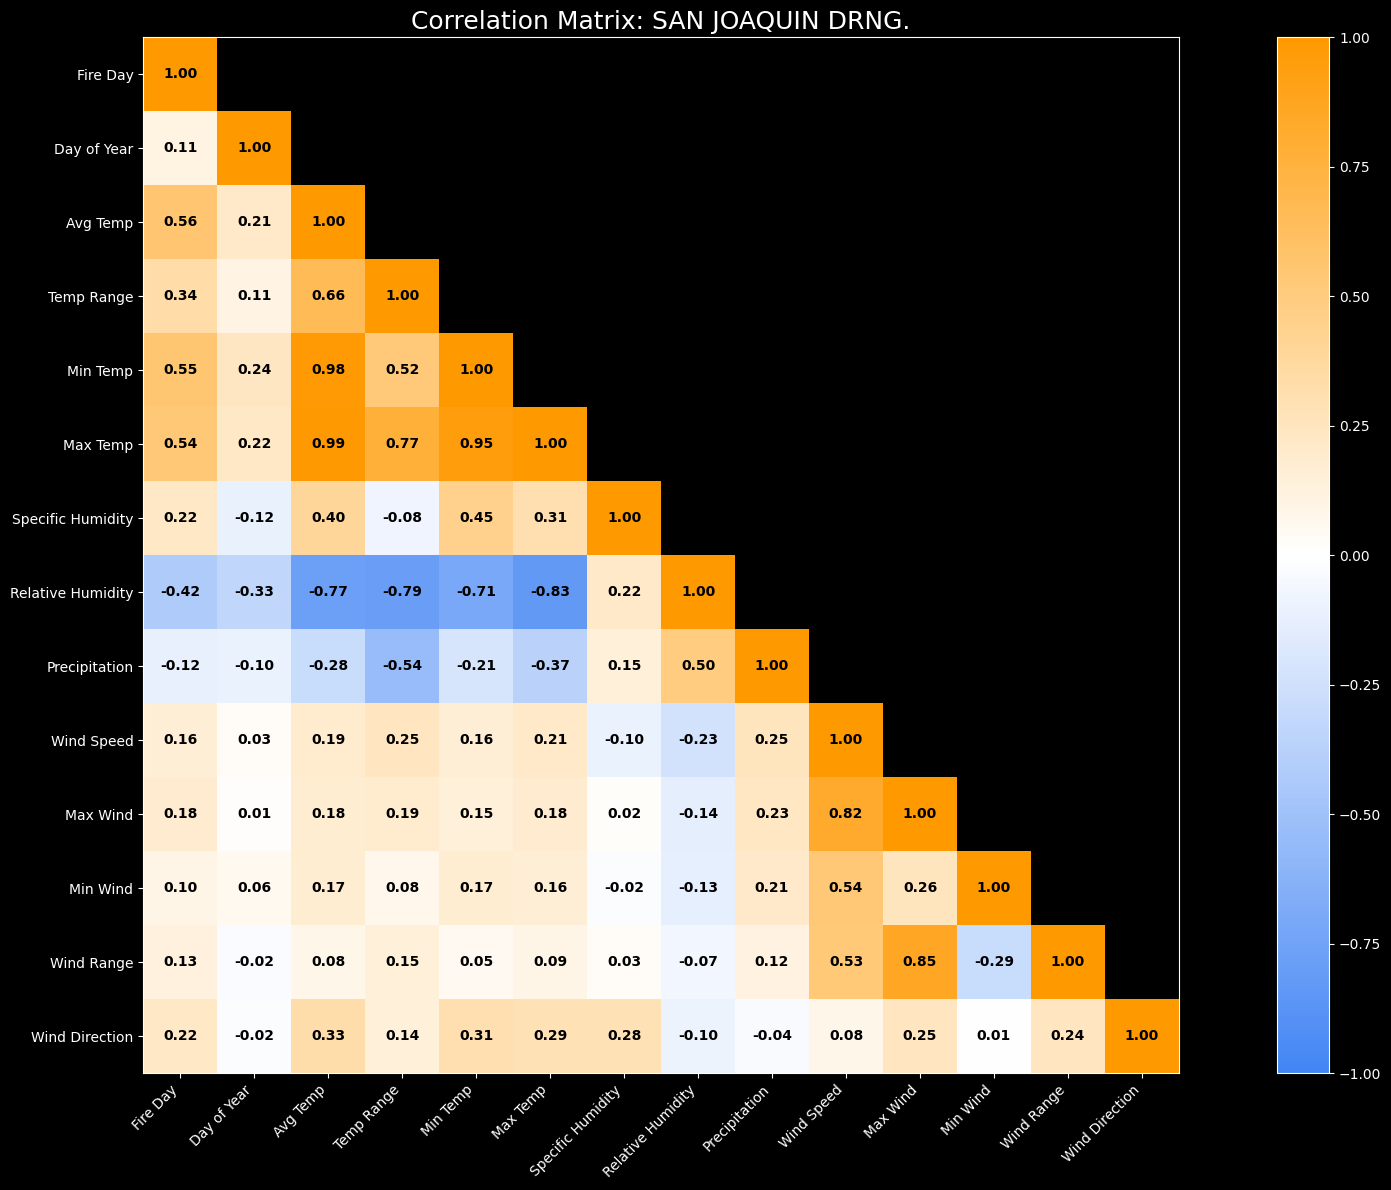

In [133]:
# use custom hex codes for color map, from blue (negative), to neutral (white) to positive (orange)
colors = ['#4285F4', '#FFFFFF', '#FF9900']
custom_cmap = LinearSegmentedColormap.from_list("blue_orange", colors, N=256)

# generate correlation heatmap figure, using matplotlib because of bugs with seaborn labels
plt.figure(figsize=(20, 12))
plt.style.use('dark_background')
fig = plt.gcf()
fig.patch.set_facecolor('black')
plt.gca().set_facecolor('black')

# generate mask
masked_corr = np.ma.array(corr, mask=mask)

# using plt.imshow() to plotn masked correlation values
im = plt.imshow(masked_corr
                , cmap=custom_cmap
                , vmin=-1
                , vmax=1)

# add the color bar
cbar = plt.colorbar(im)

# manually add annotations (due to bug with seaborn where labels weren't visible)
for i in range(len(corr)):
    for j in range(len(corr)):
        if not mask[i, j]:
            corr_value = corr.iloc[i, j]
            plt.text(j, i
                     , f'{corr_value:.2f}'
                     , ha='center', va='center'
                     , color=text_color
                     , fontweight='bold')

# add and format labels
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right', color='white')
plt.yticks(range(len(corr)), corr.index, color='white')
plt.title('Correlation Matrix: SAN JOAQUIN DRNG.', fontsize=18, color='white')


# global formatting
plt.tight_layout()
plt.savefig('correlation_map.png',dpi=300,bbox_inches='tight',facecolor='black')
plt.show()

In [136]:
df['FIRE_START_DAY'].value_counts()

FIRE_START_DAY
False    6702
True     5724
Name: count, dtype: int64

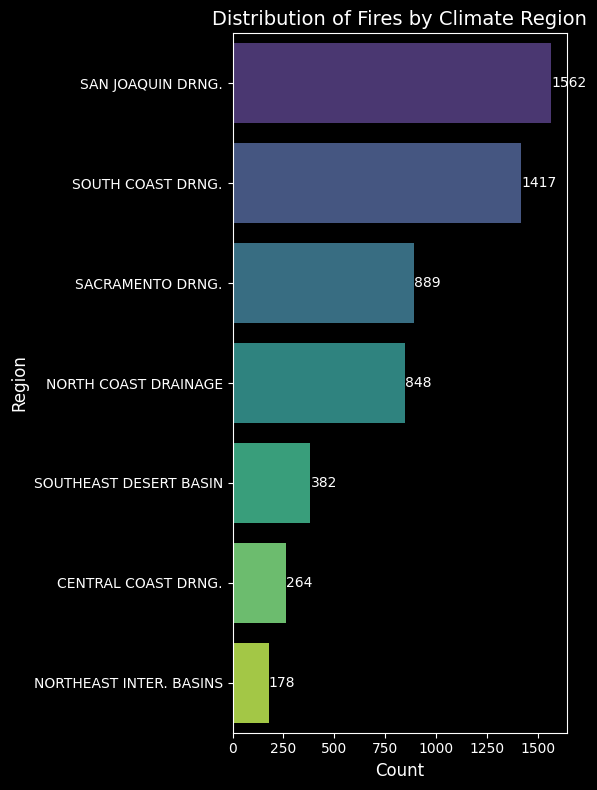

In [148]:
# get counts and exclude not_used (no fire)
counts = df['conus_name'].value_counts()
if 'not_used' in counts.index:
    counts = counts.drop('not_used')

# generarte a horizontal bar chart for the presentation
plt.figure(figsize=(6, 8))
ax = sns.barplot(x=counts.values
                 , y=counts.index
                 , orient='h'
                 , palette='viridis')

# format and add labels from the counts variable
for i, v in enumerate(counts.values):
    ax.text(v + 0.5,i,str(v), va='center')

# formatting
plt.title('Distribution of Fires by Climate Region', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Region', fontsize=12)

# global settings, export
plt.tight_layout()
plt.savefig('conus_chart.png',dpi=300,bbox_inches='tight',facecolor='black')
plt.show()

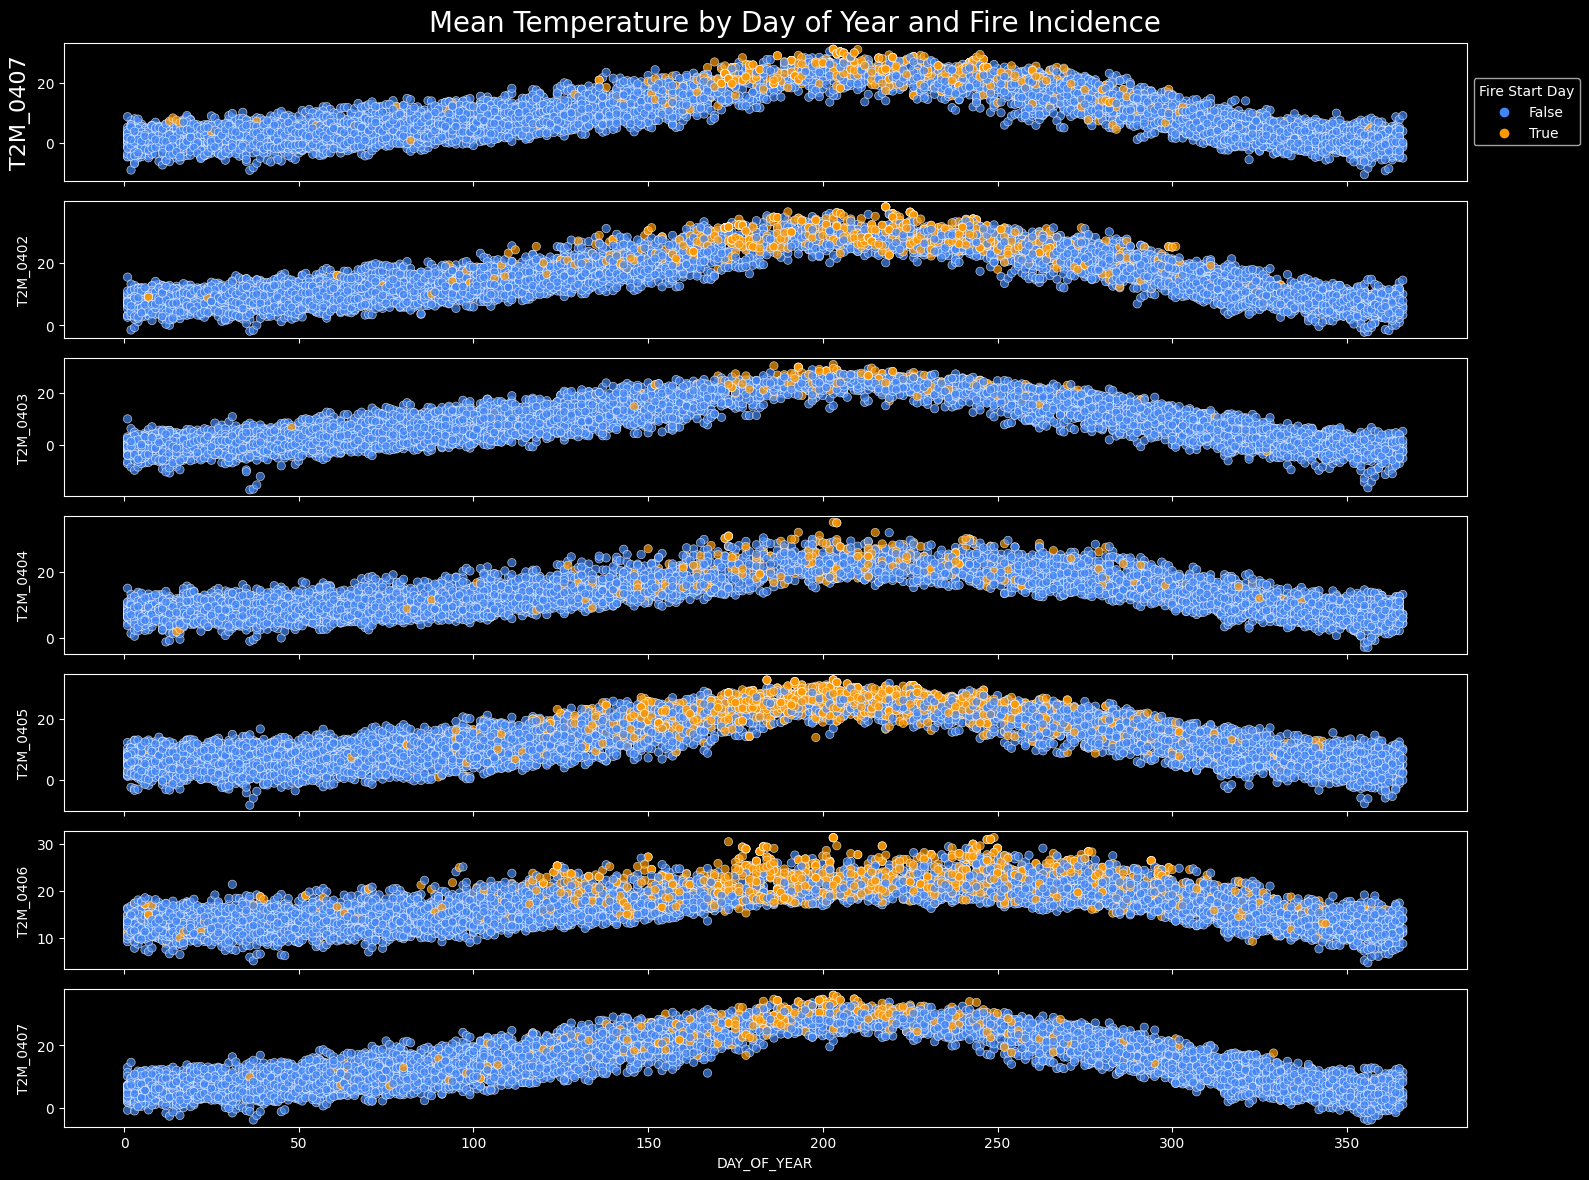

In [160]:
fig, axes = plt.subplots(7, 1, figsize=(16, 12), sharex=True)

# generate a custom palette for the scatterplot
palette = {False: '#4285F4', True: '#FF9900'} 

sns.scatterplot(x='DAY_OF_YEAR', y='T2M_0401', hue='FIRE_START_DAY',
                alpha=0.7, data=df, ax=axes[0], palette=palette)
axes[0].set_ylabel('T2M_0401', fontsize=16)
axes[0].set_title('')

# format legend to move outside of the plot
axes[0].legend(title='Fire Start Day', loc='center left', bbox_to_anchor=(1, 0.5))

sns.scatterplot(x='DAY_OF_YEAR', y='T2M_0402', hue='FIRE_START_DAY',
                alpha=0.7, data=df, ax=axes[1], palette=palette, legend = False)
axes[0].set_ylabel('T2M_0402', fontsize=16)
axes[0].set_title('')

sns.scatterplot(x='DAY_OF_YEAR', y='T2M_0403', hue='FIRE_START_DAY',
                alpha=0.7, data=df, ax=axes[2], palette=palette, legend = False)
axes[0].set_ylabel('T2M_0403', fontsize=16)
axes[0].set_title('')

sns.scatterplot(x='DAY_OF_YEAR', y='T2M_0404', hue='FIRE_START_DAY',
                alpha=0.7, data=df, ax=axes[3], palette=palette, legend = False)
axes[0].set_ylabel('T2M_0404', fontsize=16)
axes[0].set_title('')

sns.scatterplot(x='DAY_OF_YEAR', y='T2M_0405', hue='FIRE_START_DAY',
                alpha=0.7, data=df, ax=axes[4], palette=palette, legend = False)
axes[0].set_ylabel('T2M_0405', fontsize=16)
axes[0].set_title('') 

sns.scatterplot(x='DAY_OF_YEAR', y='T2M_0406', hue='FIRE_START_DAY',
                alpha=0.7, data=df, ax=axes[5], palette=palette, legend = False)
axes[0].set_ylabel('T2M_0406', fontsize=16)
axes[0].set_title('') 

sns.scatterplot(x='DAY_OF_YEAR', y='T2M_0407', hue='FIRE_START_DAY',
                alpha=0.7, data=df, ax=axes[6], palette=palette, legend = False)
axes[0].set_ylabel('T2M_0407', fontsize=16)
axes[0].set_title('') 

# global settings, export
fig.suptitle('Mean Temperature by Day of Year and Fire Incidence', fontsize=20, y=0.98)
plt.tight_layout()
plt.savefig('seasonal_chart.png',dpi=300,bbox_inches='tight',facecolor='black')
plt.show()